The main objective of this analysis is to forecast reservation demand over time using time series modeling techniques.

The study aims to:

Transform the data into a stationary time series suitable for modeling
Apply and compare different forecasting models (ARIMA and SARIMA)
Evaluate model performance using metrics such as MAE and RMSE
Identify the most accurate model for predicting future reservations
Provide insights to support decision-making, such as resource planning and demand anticipation

In [1]:
# ============================
# F.1 Imports
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
# =========================
# 1. UPLOAD CSV FILES
# =========================
import pandas as pd
from google.colab import files

print("Upload all CSV files")
uploaded = files.upload()

data = {}

for file_name in uploaded.keys():
    data[file_name] = pd.read_csv(file_name)

print("Files loaded:", list(data.keys()))

Upload all CSV files


Saving dim_localisation.csv to dim_localisation.csv
Saving dim_provider.csv to dim_provider.csv
Saving dim_service.csv to dim_service.csv
Saving dim_subcategory.csv to dim_subcategory.csv
Saving dim_suggestion.csv to dim_suggestion.csv
Saving dw_factreservations.csv to dw_factreservations.csv
Saving dim_beneficiary.csv to dim_beneficiary.csv
Saving dim_category.csv to dim_category.csv
Saving dim_complaint.csv to dim_complaint.csv
Saving dim_date.csv to dim_date.csv
Saving dim_evaluation.csv to dim_evaluation.csv
Saving dim_event.csv to dim_event.csv
Files loaded: ['dim_localisation.csv', 'dim_provider.csv', 'dim_service.csv', 'dim_subcategory.csv', 'dim_suggestion.csv', 'dw_factreservations.csv', 'dim_beneficiary.csv', 'dim_category.csv', 'dim_complaint.csv', 'dim_date.csv', 'dim_evaluation.csv', 'dim_event.csv']


In [3]:
# =========================
# 2. Récupérer les tables utiles
# =========================
dim_date = data["dim_date.csv"]
fact     = data["dw_factreservations.csv"]

print(dim_date.shape)
print(fact.shape)

display(dim_date.head())
display(fact.head())

(1461, 13)
(1010, 17)


,date_sk,date_pk,full_date,year,quarter,month,month_name,day,day_of_year,week_of_year,day_of_week,day_name,is_weekend
0,1,20220101,2022-01-01,2022,1,1,janvier,1,1,52,6,samedi,t
1,2,20220102,2022-01-02,2022,1,1,janvier,2,2,52,7,dimanche,t
2,3,20220103,2022-01-03,2022,1,1,janvier,3,3,1,1,lundi,f
3,4,20220104,2022-01-04,2022,1,1,janvier,4,4,1,2,mardi,f
4,5,20220105,2022-01-05,2022,1,1,janvier,5,5,1,3,mercredi,f


,id_reservation,reservation_sk,service_sk,event_sk,complaint_sk,beneficiary_sk,provider_sk,subcategory_sk,date_sk,localisation_sk,budget,rating,price,marketing_spend,new_beneficiaries,visitors,reservations
0,14,700,16515,7604,2049,1143,15315,17952,20220800,2,0,5,2033,20156,822,4392,270
1,10000,1010,15891,10250,1926,2091,14729,17953,50,38,25360,5,1793,9827,794,6433,300
2,10004,1014,15464,10458,821,3974,14682,17951,80,8,51040,5,5201,29203,1286,13755,300
3,10010,1020,15662,486,1451,3058,15237,17954,95,14,6691,4,639,16348,1006,12905,300
4,10011,1021,16946,7706,1704,3562,14973,17953,88,17,8503,4,2748,20630,1293,12059,300


In [4]:
print(list(data.keys()))

['dim_localisation.csv', 'dim_provider.csv', 'dim_service.csv', 'dim_subcategory.csv', 'dim_suggestion.csv', 'dw_factreservations.csv', 'dim_beneficiary.csv', 'dim_category.csv', 'dim_complaint.csv', 'dim_date.csv', 'dim_evaluation.csv', 'dim_event.csv']


In [5]:
# =========================
# 2. EXTRACTION DES TABLES
# =========================
dim_date = data["dim_date.csv"]
fact     = data["dw_factreservations.csv"]

print("dim_date:", dim_date.shape)
print("fact:", fact.shape)

display(dim_date.head())
display(fact.head())

dim_date: (1461, 13)
fact: (1010, 17)


,date_sk,date_pk,full_date,year,quarter,month,month_name,day,day_of_year,week_of_year,day_of_week,day_name,is_weekend
0,1,20220101,2022-01-01,2022,1,1,janvier,1,1,52,6,samedi,t
1,2,20220102,2022-01-02,2022,1,1,janvier,2,2,52,7,dimanche,t
2,3,20220103,2022-01-03,2022,1,1,janvier,3,3,1,1,lundi,f
3,4,20220104,2022-01-04,2022,1,1,janvier,4,4,1,2,mardi,f
4,5,20220105,2022-01-05,2022,1,1,janvier,5,5,1,3,mercredi,f


,id_reservation,reservation_sk,service_sk,event_sk,complaint_sk,beneficiary_sk,provider_sk,subcategory_sk,date_sk,localisation_sk,budget,rating,price,marketing_spend,new_beneficiaries,visitors,reservations
0,14,700,16515,7604,2049,1143,15315,17952,20220800,2,0,5,2033,20156,822,4392,270
1,10000,1010,15891,10250,1926,2091,14729,17953,50,38,25360,5,1793,9827,794,6433,300
2,10004,1014,15464,10458,821,3974,14682,17951,80,8,51040,5,5201,29203,1286,13755,300
3,10010,1020,15662,486,1451,3058,15237,17954,95,14,6691,4,639,16348,1006,12905,300
4,10011,1021,16946,7706,1704,3562,14973,17953,88,17,8503,4,2748,20630,1293,12059,300


In [6]:
print("dim_date columns:", dim_date.columns)
print("fact columns:", fact.columns)

dim_date columns: Index(['date_sk', 'date_pk', 'full_date', 'year', 'quarter', 'month',
       'month_name', 'day', 'day_of_year', 'week_of_year', 'day_of_week',
       'day_name', 'is_weekend'],
      dtype='object')
fact columns: Index(['id_reservation', 'reservation_sk', 'service_sk', 'event_sk',
       'complaint_sk', 'beneficiary_sk', 'provider_sk', 'subcategory_sk',
       'date_sk', 'localisation_sk', 'budget', 'rating', 'price',
       'marketing_spend', 'new_beneficiaries', 'visitors', 'reservations'],
      dtype='object')


In [7]:
# =========================
# 3. CREATION TIME SERIES
# =========================

# convertir en date
dim_date["full_date"] = pd.to_datetime(dim_date["full_date"])

# merge date + fact
ts_df = dim_date.merge(fact, on="date_sk", how="inner")

print("Merged shape:", ts_df.shape)
display(ts_df.head())

Merged shape: (1000, 29)


,date_sk,date_pk,full_date,year,quarter,month,month_name,day,day_of_year,week_of_year,...,provider_sk,subcategory_sk,localisation_sk,budget,rating,price,marketing_spend,new_beneficiaries,visitors,reservations
0,2,20220102,2022-01-02,2022,1,1,janvier,2,2,52,...,15339,17951,19,60875,4,7057,29698,799,461,39
1,2,20220102,2022-01-02,2022,1,1,janvier,2,2,52,...,14770,17953,42,31897,2,2980,13378,463,1107,181
2,4,20220104,2022-01-04,2022,1,1,janvier,4,4,1,...,15099,17952,43,59768,2,6663,23768,807,2257,300
3,5,20220105,2022-01-05,2022,1,1,janvier,5,5,1,...,15140,17953,13,33922,5,1991,18495,832,902,117
4,8,20220108,2022-01-08,2022,1,1,janvier,8,8,1,...,14825,17952,26,9828,4,1117,15403,767,3013,300


In [8]:
# =========================
# 4. AGGREGATION PAR JOUR
# =========================

daily_ts = ts_df.groupby("full_date")["reservations"].sum().reset_index()

# trier
daily_ts = daily_ts.sort_values("full_date")

# index temps
daily_ts.set_index("full_date", inplace=True)

# gérer valeurs manquantes
daily_ts["reservations"] = daily_ts["reservations"].fillna(0)

print(daily_ts.shape)
display(daily_ts.head())
display(daily_ts.tail())

(90, 1)


,reservations
full_date,
2022-01-02,220
2022-01-04,300
2022-01-05,117
2022-01-08,300
2022-01-09,368


,reservations
full_date,
2022-04-06,12000
2022-04-07,10800
2022-04-08,10800
2022-04-09,14100
2022-04-10,13200


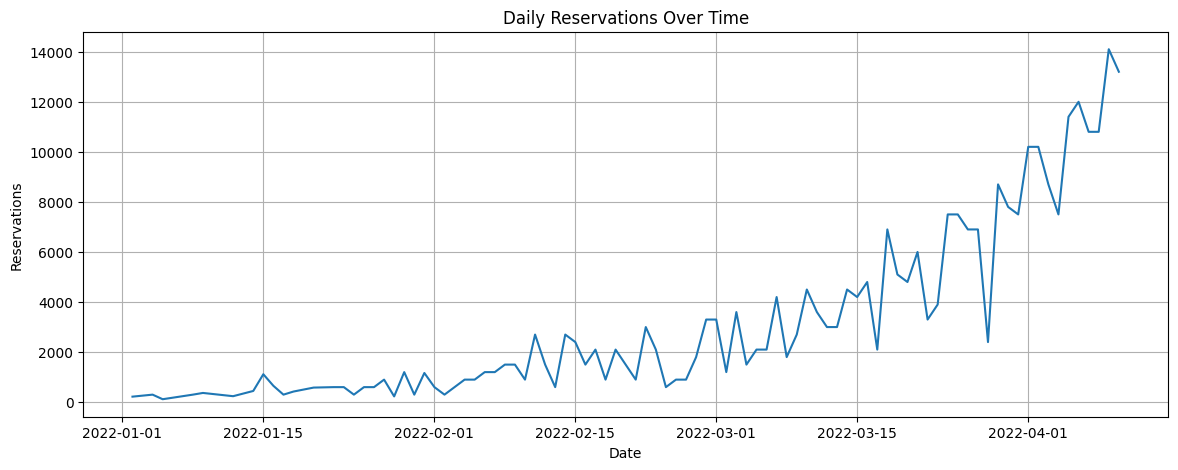

In [9]:
# =========================
# 5. VISUALISATION
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(daily_ts.index, daily_ts["reservations"])
plt.title("Daily Reservations Over Time")
plt.xlabel("Date")
plt.ylabel("Reservations")
plt.grid(True)
plt.show()

In [11]:
# =========================
# 6. TEST ADF
# =========================

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(daily_ts["reservations"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: 4.545256104776496
p-value: 1.0
Critical Value (1%): -3.5159766913976376
Critical Value (5%): -2.898885703483903
Critical Value (10%): -2.5866935058484217


In [12]:
# =========================
# 7. TEST KPSS
# =========================

from statsmodels.tsa.stattools import kpss

kpss_result = kpss(daily_ts["reservations"], regression='c', nlags="auto")

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

for key, value in kpss_result[3].items():
    print(f"Critical Value ({key}): {value}")

KPSS Statistic: 1.3379864163282318
p-value: 0.01
Critical Value (10%): 0.347
Critical Value (5%): 0.463
Critical Value (2.5%): 0.574
Critical Value (1%): 0.739


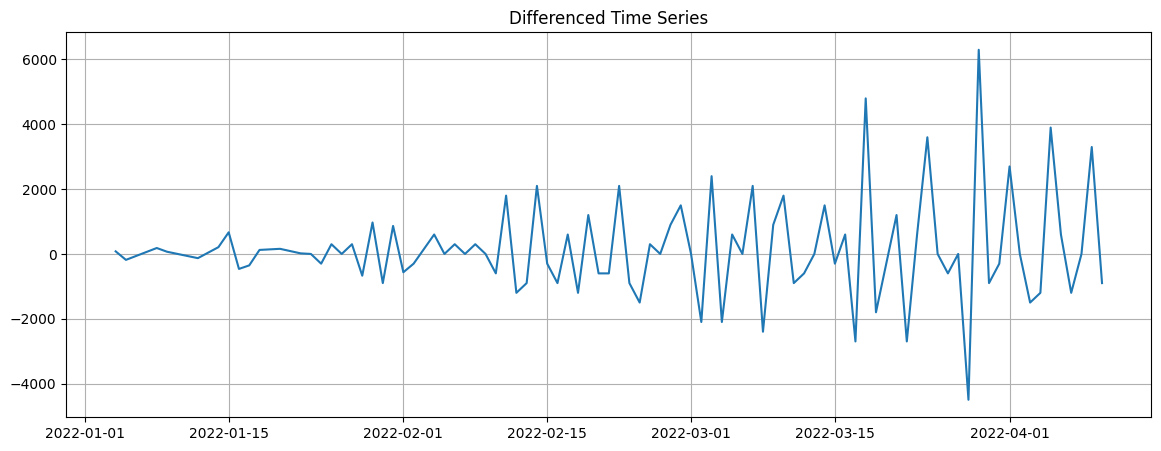

In [13]:
# =========================
# 8. DIFFERENCING
# =========================

daily_ts["diff"] = daily_ts["reservations"].diff()

# supprimer NaN
ts_diff = daily_ts["diff"].dropna()

plt.figure(figsize=(14,5))
plt.plot(ts_diff)
plt.title("Differenced Time Series")
plt.grid(True)
plt.show()

In [14]:
# =========================
# 9. ADF AFTER DIFFERENCING
# =========================

from statsmodels.tsa.stattools import adfuller

adf_diff = adfuller(ts_diff)

print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

ADF Statistic: 0.9556763134115462
p-value: 0.993775553252275


The Augmented Dickey-Fuller (ADF) test performed on the differenced time series yields a high p-value (> 0.05), indicating that the series is still non-stationary. This suggests that a single differencing step is not sufficient to remove all non-stationarity components. Additional transformations, such as second-order differencing or other preprocessing techniques, are required to achieve stationarity before applying time series forecasting models.

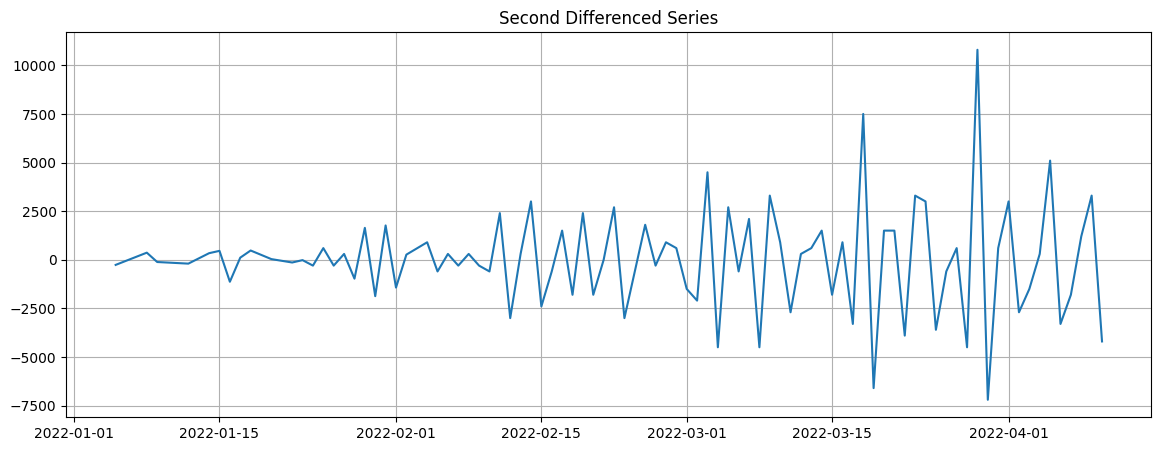

In [15]:
# =========================
# 10. SECOND DIFFERENCING
# =========================

daily_ts["diff2"] = daily_ts["reservations"].diff().diff()

ts_diff2 = daily_ts["diff2"].dropna()

plt.figure(figsize=(14,5))
plt.plot(ts_diff2)
plt.title("Second Differenced Series")
plt.grid(True)
plt.show()

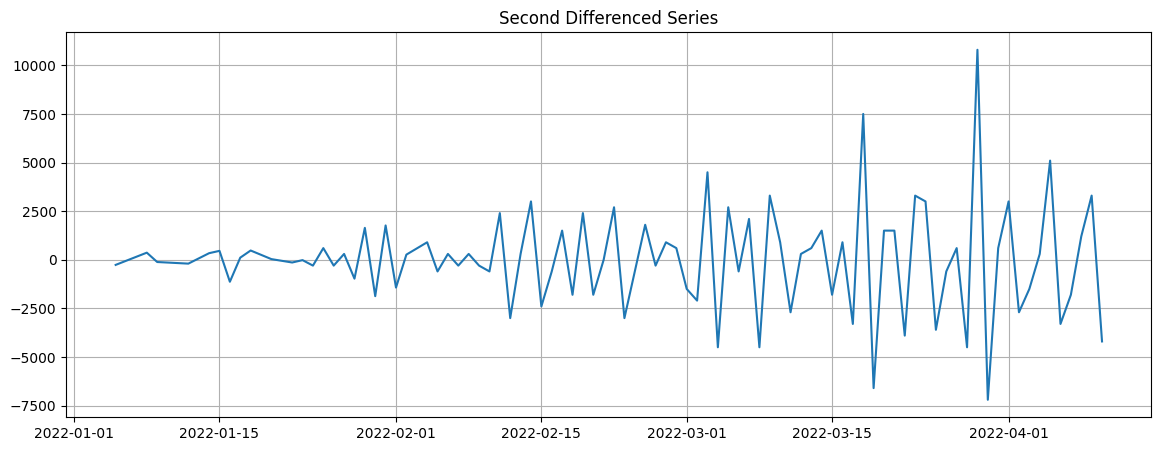

In [16]:
# =========================
# 10. SECOND DIFFERENCING
# =========================

daily_ts["diff2"] = daily_ts["reservations"].diff().diff()

ts_diff2 = daily_ts["diff2"].dropna()

plt.figure(figsize=(14,5))
plt.plot(ts_diff2)
plt.title("Second Differenced Series")
plt.grid(True)
plt.show()

In [17]:
from statsmodels.tsa.stattools import adfuller

adf_diff2 = adfuller(ts_diff2)

print("ADF Statistic:", adf_diff2[0])
print("p-value:", adf_diff2[1])

ADF Statistic: -4.060039285778241
p-value: 0.0011267836053959698


The Augmented Dickey-Fuller (ADF) test applied on the second differenced series shows a p-value lower than 0.05, indicating that the null hypothesis of non-stationarity is rejected. Therefore, the time series is considered stationary after second-order differencing (d = 2). This confirms that the transformation successfully removed trend and non-stationary components, making the data suitable for time series modeling.

In [18]:
# =========================
# 12. TRAIN / TEST SPLIT
# =========================

train_size = int(len(daily_ts) * 0.8)

train = daily_ts["reservations"][:train_size]
test  = daily_ts["reservations"][train_size:]

print("Train:", len(train))
print("Test:", len(test))

Train: 72
Test: 18


In [19]:
# =========================
# 13. ARIMA MODEL
# =========================

from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train, order=(1,2,1))
model_arima_fit = model_arima.fit()

forecast_arima = model_arima_fit.forecast(steps=len(test))

In [20]:
# =========================
# 14. SARIMA MODEL
# =========================

from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    train,
    order=(1,2,1),
    seasonal_order=(1,1,1,7)  # saison hebdo
)

model_sarima_fit = model_sarima.fit(disp=False)

forecast_sarima = model_sarima_fit.forecast(steps=len(test))

In [21]:
# =========================
# 15. EVALUATION
# =========================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("-"*30)

evaluate(test, forecast_arima, "ARIMA")
evaluate(test, forecast_sarima, "SARIMA")

ARIMA
MAE: 5112.611584506402
RMSE: 5533.229625272103
------------------------------
SARIMA
MAE: 5080.597810898777
RMSE: 5480.881203131219
------------------------------


Two forecasting models were implemented: ARIMA and SARIMA. The models were evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

The SARIMA model achieved slightly better performance than ARIMA, with lower MAE (5080.60 vs 5112.61) and RMSE (5480.88 vs 5533.23). This indicates that SARIMA provides more accurate predictions.

The improvement is due to SARIMA’s ability to capture seasonality patterns in the data, which are not considered in the standard ARIMA model.

Therefore, SARIMA is selected as the best model for forecasting reservations in this project.

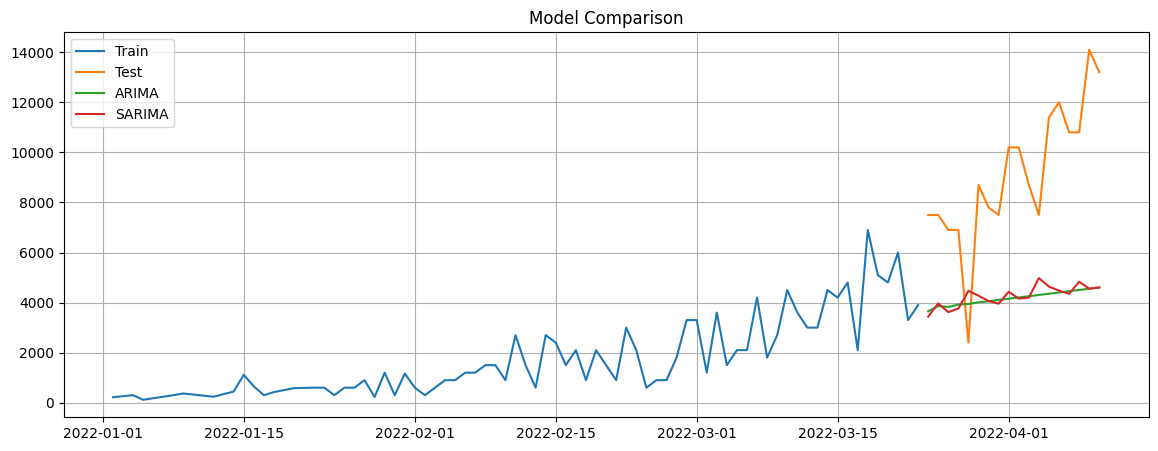

In [22]:
# =========================
# 16. VISUALISATION
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")

plt.plot(test.index, forecast_arima, label="ARIMA")
plt.plot(test.index, forecast_sarima, label="SARIMA")

plt.legend()
plt.title("Model Comparison")
plt.grid(True)
plt.show()

The comparison shows that both ARIMA and SARIMA capture the overall trend but fail to follow the sharp increase in actual reservations. Predictions are smoother and underestimate peak values.

SARIMA performs slightly better, as it is closer to real values and has lower MAE and RMSE.

However, both models struggle with high volatility, suggesting that more advanced models could improve forecasting accuracy.